# Bepaling van soortelijke warmte van water


# Introductie

Water heeft een enorme buffercapaciteit: je moet veel energie toevoegen om de temperatuur van water een graad te verwarmen. In dit practicum gaan we de soortelijke warmte van water bepalen door een bekende hoeveelheid water te verwarmen met een bekende hoeveelheid energie, en de temperatuurstijging te meten.

# Theorie

Geef hier de natuurkundige achtergrond van het onderwerp. 

# Methode en materialen

## Ontwerp
Een waterbad met bekende massa aan water wordt verwarmd met een elektrisch verwarmingselement dat een bekende hoeveelheid energie levert.
De temperatuur van het water wordt gemeten met een temperatuursensor.
Door de temperatuurstijging als functie van de tijd te meten kan de soortelijke warmte van water worden berekend.


## Materialen
Hieronder staat de lijst van benodigde materialen bij deze proef:
- Maatbeker
- Weegschaal
- Water
- Elektrisch verwarmingselement ($10 \mathrm{\Omega}$, $10 \mathrm{W}$)
- Voedingsbron 
- Thermometer of temperatuursensor
- Stopwatch of timer

```{figure} figures/cwater_setup.jpg
:width: 70%

Een schematische weergave van de opstelling
```

## Procedure
```{exercise}
1. Beschrijf de procedure die nodig is om de soortelijke warmte van water te bepalen.
2. Geef jouw beschrijving van de procedure aan een ander team, zij verzamelen voor jou de data op basis van de gegevens.
3. Voer het experiment van een ander team uit op basis van hun beschrijving.
4. Analyseer de data die het andere groepje voor jou heeft verzameld.
```


## Veiligheid
We maken gebruik van een $10 \mathrm{\Omega}$, $10 \mathrm{W}$ weerstand.
Deze wordt snel heet.
De bronspanning mag dan ook alleen aan wanneer de weerstand in het water zit.
Raak de weerstand niet aan tijdens het experiment.
Omdat de weerstand in het water zit, kunnen we wel het elektrisch vermogen hoger zetten zonder dat de weerstand oververhit raakt.
Het maximaal vermogen mag $40 \mathrm{W}$ zijn.
Daarbij moet de roerder wel aanstaan om de warmte goed te verdelen.

## Data analyse
Geef kort de data-analysemethode weer.

1. Massa van het water bepalen
Weeg de lege maatbeker.

Vul de maatbeker met 400–600 mL water.

Weeg de maatbeker opnieuw.

Bereken de massa van het water:

m_water = m_beker+water − m_beker

2. Temperatuursensor plaatsen
Plaats de thermometer of temperatuursensor in het midden van het water.

Wacht 20–30 seconden tot de meting stabiel is.

Noteer de begintemperatuur.

3. Verwarmingselement voorbereiden
Hang of klem de 10 Ω, 10 W weerstand volledig onder water.

Zorg dat de weerstand de bekerwand niet raakt.

Zet de roerder aan zodat de warmte gelijkmatig verdeeld wordt.

4. Start van het experiment
Start de stopwatch.

Zet de voeding aan op 12 V. (De spanning mag alleen aan wanneer de weerstand al in het water zit.)

Noteer elke 30 de temperatuur van het water.

5. Elektrisch vermogen bepalen
Meet de spanning over de weerstand (U).

Meet de stroom door de weerstand (I).

Bereken het vermogen:

P = U * I

Bereken de toegevoerde energie:

E = P * t

waarbij t de totale opwarmtijd is in seconden.

6. Stop het experiment
Zet de voeding uit.

Haal de weerstand voorzichtig uit het water (hij blijft heet).

Noteer de eindtemperatuur.

7. Bereken de soortelijke warmte van water
Gebruik:

c = E / (m * ΔT)

waarbij:

E = toegevoerde energie (J)

m = massa van het water (kg)

ΔT = temperatuurstijging (°C)

# Resultaten


### Verkregen gegevens (gemeten door een andere groep met onze meetprocedure)

### Data en analyse:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
m = 584.e-3                     # massa water in kg
T_begin = 20.2                  # begintemperatuur van water in K
T_eind = 22.9                   # eindtemperatuur van water in K
T_raw = np.array([20.2, 20.4, 20.6, 20.8, 21.0, 21.2, 21.4, 21.6, 21.8, 22.0, 22.3, 22.5, 22.7, 22.9])    # gemeten temperaturen in graden Celsius
t = np.arange(0,391,30)         # tijdsintervallen in seconden
V = 13.6                        # gemeten spanning in Volt
I = 1.39                        # gemeten stroom in Ampère

P = 18.90 W
E = [   0.    567.12 1134.24 1701.36 2268.48 2835.6  3402.72 3969.84 4536.96
 5104.08 5671.2  6238.32 6805.44 7372.56]  J

Stijgsnelheid dT/dt = 0.0070 °C/s

Berekende soortelijke warmte c = 4651.04 J/(kg·°C)


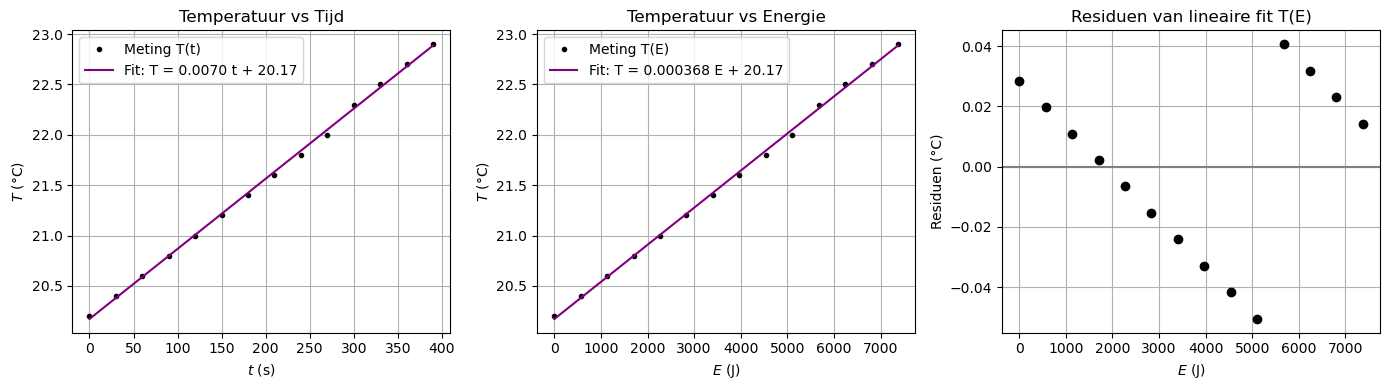

In [16]:

P = V * I       # vermogen in Watt
E = P * t       # toegevoerde energie in Joule

print(f"P = {P:.2f} W")
print("E =", E," J")

def func(x, a, b):
    return a*x + b          # T(t) = (dT/dt)*t + T_0

popt, pcov = curve_fit(func, t, T_raw)
slope_fit_T, T_0_fit = popt
T_fit = func(t, slope_fit_T, T_0_fit)

plt.figure(figsize=(14,4))
plt.subplot(1,3,1)
plt.plot(t, T_raw, "o", label="Meting T(t)", color='black', markersize=3)
plt.plot(t, T_fit, label=f"Fit: T = {slope_fit_T:.4f} t + {T_0_fit:.2f}", color='purple')
plt.xlabel("$t$ (s)")
plt.ylabel("$T$ (°C)")
plt.title("Temperatuur vs Tijd")
plt.grid(True)
plt.legend()
plt.savefig(r"C:\Users\l.hekman\TNfolder\Project\thermolab\Figures\c_water_1_Tvst.png", dpi=450)

print(f"\nStijgsnelheid dT/dt = {slope_fit_T:.4f} °C/s")

popt2, pcov2 = curve_fit(func, E, T_raw)
slope_fit_E, T_0_fit = popt2
T_fit_E = func(E, slope_fit_E, T_0_fit)

plt.subplot(1,3,2)
plt.plot(E, T_raw, "o", label="Meting T(E)", color='black', markersize=3)
plt.plot(E, T_fit_E, label=f"Fit: T = {slope_fit_E:.6f} E + {T_0_fit:.2f}", color='purple')
plt.xlabel("$E$ (J)")
plt.ylabel("$T$ (°C)")
plt.title("Temperatuur vs Energie")
plt.grid(True)
plt.legend()
plt.savefig(r"C:\Users\l.hekman\TNfolder\Project\thermolab\Figures\c_water_1_TvsE.png", dpi=450)

c = 1 / (m * slope_fit_E)           # Soortelijke warmte berekenen in J/(kg·°C)
print(f"\nBerekende soortelijke warmte c = {c:.2f} J/(kg·°C)")

residuals = T_raw - T_fit_E

plt.subplot(1,3,3)
plt.axhline(0, color='gray')
plt.plot(E, residuals, "o", color='black')
plt.xlabel("$E$ (J)")
plt.ylabel("Residuen (°C)")
plt.title("Residuen van lineaire fit T(E)")
plt.grid(True)
plt.savefig(r"C:\Users\l.hekman\TNfolder\Project\thermolab\Figures\c_water_1_residuals.png", dpi=450)
plt.tight_layout()
plt.show()

### Verkregen gegevens (gemeten door ons met de meetprocedure van een andere groep):

### Data en analyse:

In [4]:
m2 = 584.e-3                # massa water in kg
T_begin2 = 19.7             # begintemperatuur van water in K
T_eind2 = 29.0              # eindtemperatuur van water in K
T_raw2 = np.array([19.7, 20.8, 21.8, 22.7, 23.4, 24.1, 24.9, 25.6, 26.3, 26.8, 27.6, 28.3, 29.0])    # gemeten temperaturen in graden Celsius
t2 = np.arange(0,361,30)    # tijdsintervallen in seconden
V2 = 18.9                   # gemeten spanning in Volt
I2 = 1.94                   # gemeten stroom in Ampère

P = 36.67 W
E = [    0.    1099.98  2199.96  3299.94  4399.92  5499.9   6599.88  7699.86
  8799.84  9899.82 10999.8  12099.78 13199.76]  J

Stijgsnelheid dT/dt = 0.0249 °C/s

Berekende soortelijke warmte c = 2518.75 J/(kg·°C)


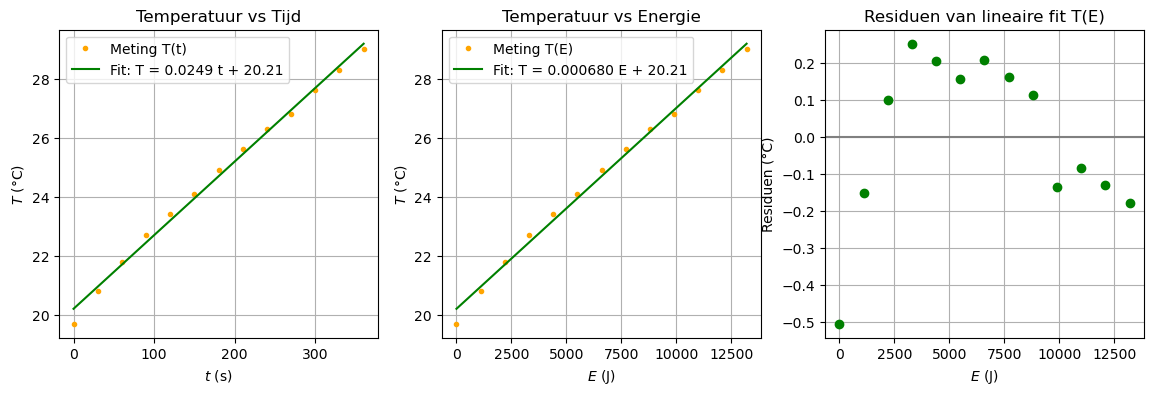

In [19]:
P2 = V2 * I2       # vermogen in Watt
E2 = P2 * t2       # toegevoerde energie in Joule

print(f"P = {P2:.2f} W")
print("E =", E2," J")

def funky(x, a, b):
    return a*x + b          # T(t) = (dT/dt)*t + T_0

popt3, pcov3 = curve_fit(funky, t2, T_raw2)
slope_fit_T2, T_0_fit2 = popt3
T_fit2 = funky(t2, slope_fit_T2, T_0_fit2)

plt.figure(figsize=(14,4))
plt.subplot(1,3,1)
plt.plot(t2, T_raw2, "o", label="Meting T(t)", color='orange', markersize=3)
plt.plot(t2, T_fit2, label=f"Fit: T = {slope_fit_T2:.4f} t + {T_0_fit2:.2f}", color='green')
plt.xlabel("$t$ (s)")
plt.ylabel("$T$ (°C)")
plt.title("Temperatuur vs Tijd")
plt.grid(True)
plt.legend()
plt.savefig(r"C:\Users\l.hekman\TNfolder\Project\thermolab\Figures\c_water_2_Tvst.png", dpi=450)

print(f"\nStijgsnelheid dT/dt = {slope_fit_T2:.4f} °C/s")

popt4, pcov4 = curve_fit(funky, E2, T_raw2)
slope_fit_E2, T_0_fit_E2 = popt4
T_fit_E2 = funky(E2, slope_fit_E2, T_0_fit_E2)

plt.subplot(1,3,2)
plt.plot(E2, T_raw2, "o", label="Meting T(E)", color='orange', markersize=3)
plt.plot(E2, T_fit_E2, label=f"Fit: T = {slope_fit_E2:.6f} E + {T_0_fit_E2:.2f}", color='green')
plt.xlabel("$E$ (J)")
plt.ylabel("$T$ (°C)")
plt.title("Temperatuur vs Energie")
plt.grid(True)
plt.legend()
plt.savefig(r"C:\Users\l.hekman\TNfolder\Project\thermolab\Figures\c_water_2_TvsE.png", dpi=450)

c2 = 1 / (m2 * slope_fit_E2)           # Soortelijke warmte berekenen in J/(kg·°C)
print(f"\nBerekende soortelijke warmte c = {c2:.2f} J/(kg·°C)")

residuals2 = T_raw2 - T_fit_E2

plt.subplot(1,3,3)
plt.axhline(0, color='gray')
plt.plot(E2, residuals2, "o", color='green')
plt.xlabel("$E$ (J)")
plt.ylabel("Residuen (°C)")
plt.title("Residuen van lineaire fit T(E)")
plt.grid(True)
plt.savefig(r"C:\Users\l.hekman\TNfolder\Project\thermolab\Figures\c_water_2_residuals.png", dpi=450)
plt.show()

# Discussie en conclusie

Hier een korte discussie en conclusie over de resultaten van het experiment en de implicaties daarvan.